In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import NearestNeighbors

import random
from PIL import Image
import seaborn as sns

from twin.config import DATA_DIR
from twin.embedding import SGtSNELayout
from twin.pipelines import graph_embedding_all

2026-01-30 00:48:11.867 | INFO     | twin.config:<module>:11 - PROJ_ROOT path is: /home/alex/Projects/twin


In [2]:
n_obj = 20
n_image_per_obj = 72
n_samples = n_obj * n_image_per_obj

width = 64
height = 64
features = width * height

COIL_20_DIR = DATA_DIR / "point-cloud/coil-20"
COIL_20_IMAGE_DIR = COIL_20_DIR / "images"

In [3]:
X = np.zeros((n_samples, features))
for i in range(n_obj):
    for j in range(n_image_per_obj):
        with Image.open(str(COIL_20_IMAGE_DIR / f"{i+1}/obj{i+1}__{j}.png")) as img:
            X[j + n_image_per_obj*i] = np.asarray(img.resize((width, height))).flatten()
            X[j + n_image_per_obj*i] /= np.max(X[j + n_image_per_obj*i])

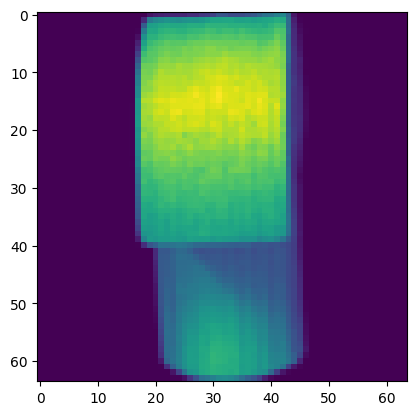

In [4]:
plt.imshow(X[random.randrange(0,n_samples)].reshape((height, width)))

In [5]:
palette = sns.color_palette('hls', 20)
palette

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.5272, 0.33999999999999997),
 (0.86, 0.6832, 0.33999999999999997),
 (0.86, 0.8392000000000002, 0.33999999999999997),
 (0.7247999999999999, 0.86, 0.33999999999999997),
 (0.5688000000000001, 0.86, 0.33999999999999997),
 (0.41279999999999994, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.42320000000000013),
 (0.33999999999999997, 0.86, 0.5792000000000002),
 (0.33999999999999997, 0.86, 0.7352000000000001),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.6727999999999997, 0.86),
 (0.33999999999999997, 0.5167999999999995, 0.86),
 (0.33999999999999997, 0.36079999999999973, 0.86),
 (0.4752000000000003, 0.33999999999999997, 0.86),
 (0.6311999999999998, 0.33999999999999997, 0.86),
 (0.7871999999999999, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.7767999999999993),
 (0.86, 0.33999999999999997, 0.6207999999999999),
 (0.86, 0.33999999999999997, 0.46479999999999977)]

In [6]:
rng = np.random.default_rng(seed=0)
palette = rng.permutation(palette, axis=0)

In [7]:
colors = np.repeat(palette, n_image_per_obj, axis=0)

In [8]:
knn = NearestNeighbors(n_neighbors=12).fit(X)
adj = knn.kneighbors_graph(mode='distance').toarray()
G = nx.from_numpy_array(adj)

In [9]:
experiment = graph_embedding_all(
    G, embedding=SGtSNELayout,
    twinmatrix_kw={'alpha': 0.85, 'k': 2},
    embedding_kw={'lambda_par': 10},
    seed=1
)

In [10]:
y_v = experiment['VertexEmbedding']['V']
y_tw = experiment['TwinEmbedding']['V']

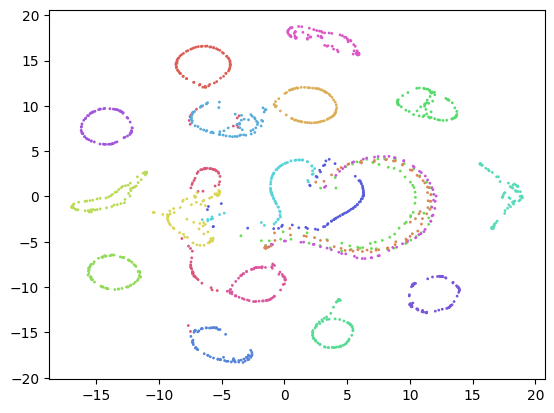

In [11]:
plt.scatter(*y_v, s=1, c=colors)

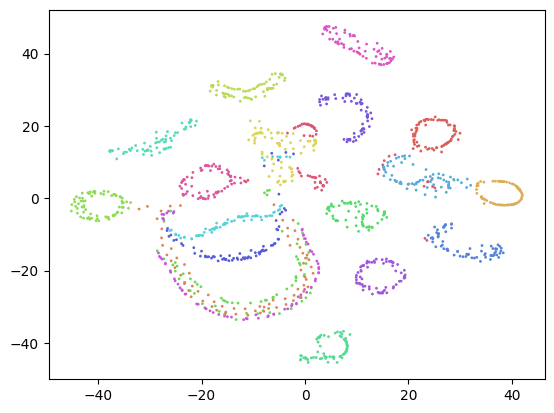

In [12]:
plt.scatter(*y_tw, s=1, c=colors)